In [ ]:
"""
.. _uoi_lasso:

UoI-Lasso for sparse, minimal bias, regression
==============================================

This example with demonstrate the ability of UoI-Lasso to recover sparse
models with minimal bias.

"""

###############################################################################
# Load synthetic data
# -------------------
#
# The synthetic data will have 40 features, 10 of which are informative and
# 1 response variable.


import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression, LassoCV

from pyuoi.linear_model import UoI_Lasso
from pyuoi.datasets import make_linear_regression
import pandas as pd
from scipy.linalg import solve_discrete_lyapunov

In [11]:
def mbbs_new(data, n_blocks=10, block_length=None):
    # number of datapoints
    n = len(data)
    
    # assign a default value for block_length
    if block_length is None:
        block_length = n // n_blocks
        
    # Create empty DataFrame with correct size and columns
    total_rows = n_blocks * block_length
    mbbs_sample = pd.DataFrame(columns=data.columns, index=range(total_rows))
    
    # generate starting indices for each block
    block_indices = np.random.randint(low=0, high=n - block_length, size=n_blocks)
    
    # Create the bootstrap sample
    for i in range(n_blocks):
        start_index = block_indices[i]
        end_index = start_index + block_length
        mbbs_sample.iloc[i * block_length : (i + 1) * block_length] = data.iloc[start_index:end_index].values
        
    return mbbs_sample

In [12]:


def generate_stable_var_process(n_features, n_samples, lag=1, random_state=None):
    """
    Generate data from a stable Vector Autoregressive (VAR) process.
    
    Parameters:
    -----------
    n_features : int
        Number of features (dimensions) in the VAR process
    n_samples : int
        Number of time points to generate
    lag : int, default=1
        Order of the VAR process (number of past observations to use)
    random_state : int or None, default=None
        Random seed for reproducibility
    
    Returns:
    --------
    tuple:
        - data: ndarray of shape (n_samples, n_features)
        - transition_matrices: list of ndarrays, each of shape (n_features, n_features)
        - covariance_matrix: ndarray of shape (n_features, n_features)
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    def is_stable(matrices):
        """Check if VAR process is stable by examining eigenvalues"""
        # Create companion matrix
        n = matrices[0].shape[0]
        p = len(matrices)
        companion = np.zeros((n * p, n * p))
        
        # Fill in the companion matrix
        companion[:n] = np.hstack(matrices)
        if p > 1:
            companion[n:, :-n] = np.eye(n * (p - 1))
            
        # Check eigenvalues
        eigenvals = np.linalg.eigvals(companion)
        return np.all(np.abs(eigenvals) < 1)
    
    # Generate transition matrices with controlled spectral radius
    transition_matrices = []
    stable = False
    
    while not stable:
        transition_matrices = []
        for _ in range(lag):
            # Generate random matrix and scale it
            matrix = np.random.randn(n_features, n_features)
            # Scale the matrix to make it more likely to produce a stable process
            matrix *= 0.5 / (lag * np.sqrt(n_features))
            transition_matrices.append(matrix)
        
        stable = is_stable(transition_matrices)
    
    # Generate innovation covariance matrix (positive definite)
    A = np.random.randn(n_features, n_features)
    covariance_matrix = A @ A.T + np.eye(n_features)
    
    # Calculate stationary covariance using discrete Lyapunov equation
    # For simplicity, we'll use the first-order approximation
    A_total = np.zeros((n_features, n_features))
    for matrix in transition_matrices:
        A_total += matrix
    
    stationary_cov = solve_discrete_lyapunov(A_total, covariance_matrix)
    
    # Initialize data with stationary distribution
    data = np.random.multivariate_normal(
        mean=np.zeros(n_features),
        cov=stationary_cov,
        size=lag
    )
    
    # Generate the rest of the time series
    for t in range(lag, n_samples):
        new_point = np.zeros(n_features)
        
        # Add contribution from each lag
        for i in range(lag):
            new_point += transition_matrices[i] @ data[t - i - 1]
            
        # Add noise
        new_point += np.random.multivariate_normal(
            mean=np.zeros(n_features),
            cov=covariance_matrix
        )
        
        data = np.vstack([data, new_point])
    
    return data, transition_matrices, covariance_matrix

def print_process_info(data, transition_matrices, covariance_matrix):
    """
    Print information about the generated VAR process.
    
    Parameters:
    -----------
    data : ndarray
        The generated time series data
    transition_matrices : list of ndarrays
        The transition matrices of the VAR process
    covariance_matrix : ndarray
        The innovation covariance matrix
    """
    print(f"Data shape: {data.shape}")
    print("\nTransition matrices:")
    for i, matrix in enumerate(transition_matrices):
        print(f"\nLag {i+1}:")
        print(matrix)
    print("\nInnovation covariance matrix:")
    print(covariance_matrix)
    
    # Print some basic statistics
    print("\nData statistics:")
    print(f"Mean:\n{np.mean(data, axis=0)}")
    print(f"\nEmpirical covariance:\n{np.cov(data.T)}")

In [17]:
# Example usage
n_features = 3
n_samples = 100
lag = 5

data, transition_matrices, covariance_matrix = generate_stable_var_process(
    n_features=n_features,
    n_samples=n_samples,
    lag=lag,
    random_state=42
)

# Print information about the generated process
print_process_info(data, transition_matrices, covariance_matrix)

Data shape: (100, 3)

Transition matrices:

Lag 1:
[[ 0.0286778  -0.00798269  0.03739432]
 [ 0.08793217 -0.01351885 -0.0135179 ]
 [ 0.09117589  0.04430786 -0.02710512]]

Lag 2:
[[ 0.03132472 -0.02675543 -0.02688892]
 [ 0.0139697  -0.11046329 -0.09958818]
 [-0.03246369 -0.05847583  0.01814308]]

Lag 3:
[[-0.05242479 -0.08153939  0.08461927]
 [-0.0130352   0.00389874 -0.08225787]
 [-0.03142995  0.00640412 -0.06645265]]

Lag 4:
[[ 0.02169094 -0.03467789 -0.01684095]
 [-0.03473955  0.10694133 -0.00077926]
 [-0.06106697  0.04748965 -0.07048544]]

Lag 5:
[[ 0.01205875 -0.11314161 -0.07668286]
 [ 0.01136579  0.04263539  0.00989395]
 [-0.00667696 -0.01738423 -0.08536251]]

Innovation covariance matrix:
[[2.84787116 0.90736938 1.23563237]
 [0.90736938 4.33141454 1.25935383]
 [1.23563237 1.25935383 1.98065964]]

Data statistics:
Mean:
[-0.3809867  -0.11200801 -0.0100858 ]

Empirical covariance:
[[2.53955487 0.33890958 0.74653013]
 [0.33890958 2.92357366 0.86189868]
 [0.74653013 0.86189868 1.9294

In [ ]:
# packageing VAR into a regression problem by vectorization

Y = np.flipud(data)[:lag]

In [26]:
ones = np.vstack([np.eye(n_features) for _ in range(lag+1)])

(18, 3)

In [19]:
U = np

(100, 3)

### LASSO probelsm

In [ ]:
matplotlib.rcParams['figure.figsize'] = [4, 4]
np.random.seed(0)

X, y, beta, intercept = make_linear_regression(n_features=40, n_informative=10,
                                               X_loc=0., beta_low=-1.,
                                               beta_high=1.)

In [28]:
X.shape

(100, 40)

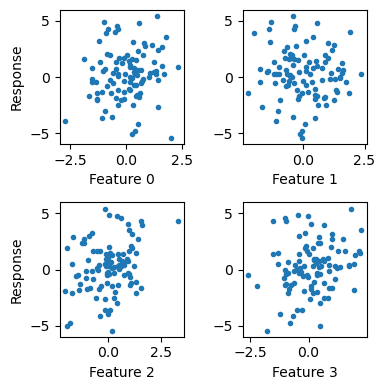

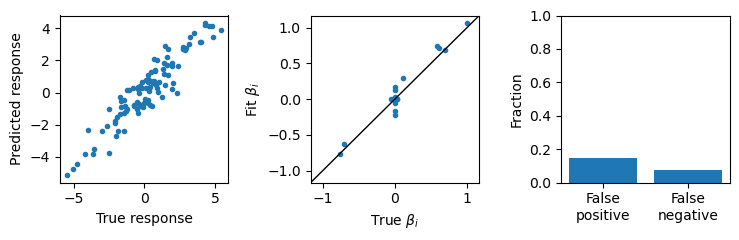

In [3]:
###############################################################################
# Visualize data
# --------------
#
# Some features are informative and others are not.


fig, axes = plt.subplots(2, 2)
for ii, ax in enumerate(axes.ravel()):
    ax.scatter(X[:, ii], y.ravel(), marker='.')
    ax.set_xlabel('Feature {}'.format(ii))
for ax in axes[:, 0]:
    ax.set_ylabel('Response')
fig.tight_layout()


###############################################################################
# Fit a UoI-Lasso model
# ---------------------
#
# UoI-Lasso can fit low bias model parameters with feature selectivity. We can
# evaluate the predictions of the model, compare the fit :math:`\beta`, and look
# at the fraction of false positive and false negatives.


uoi_lasso = UoI_Lasso()
uoi_lasso.fit(X, y)
yhat = uoi_lasso.predict(X)

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
ax = axes[0]
ax.scatter(y, yhat, marker='.')
ax.set_xlabel('True response')
ax.set_ylabel('Predicted response')

ax = axes[1]
val = max(abs(beta).max(), abs(uoi_lasso.coef_).max()) * 1.1
ax.scatter(beta.ravel(), uoi_lasso.coef_.ravel(), marker='.')
ax.set_xlabel(r'True $\beta_i$')
ax.set_ylabel(r'Fit $\beta_i$')
ax.set_xlim(-val, val)
ax.set_ylim(-val, val)
ax.plot([-val, val], [-val, val], c='k', lw=1.)

ax = axes[2]
fp = np.logical_and(uoi_lasso.coef_ != 0, beta == 0).mean()
fn = np.logical_and(uoi_lasso.coef_ == 0, beta != 0).mean()
ax.bar([0, 1], [fp, fn], align='center')
ax.set_xticks([0, 1])
ax.set_xticklabels(['False\npositive', 'False\nnegative'])
ax.set_ylabel('Fraction')
ax.set_ylim(0, 1)
fig.tight_layout()